In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB # Naive bayes multinomial para clasificación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score # Métrica de evaluación

# Análisis Exploratorio

In [2]:
df_nasa = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/asteroids_nasa.csv')
df_nasa.head(5)

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


Verificamos los tipos de datos

In [3]:
df_nasa.dtypes

Neo Reference ID                  int64
Name                              int64
Absolute Magnitude              float64
Est Dia in KM(min)              float64
Est Dia in KM(max)              float64
Est Dia in M(min)               float64
Est Dia in M(max)               float64
Est Dia in Miles(min)           float64
Est Dia in Miles(max)           float64
Est Dia in Feet(min)            float64
Est Dia in Feet(max)            float64
Close Approach Date              object
Epoch Date Close Approach         int64
Relative Velocity km per sec    float64
Relative Velocity km per hr     float64
Miles per hour                  float64
Miss Dist.(Astronomical)        float64
Miss Dist.(lunar)               float64
Miss Dist.(kilometers)          float64
Miss Dist.(miles)               float64
Orbiting Body                    object
Orbit ID                          int64
Orbit Determination Date         object
Orbit Uncertainity                int64
Minimum Orbit Intersection      float64


In [4]:
print("Tamaño del dataframe : {}".format(df_nasa.shape))

Tamaño del dataframe : (4687, 40)


Verificamos si hay valores nulos para imputar

In [5]:
df_nasa.isnull().sum()

Neo Reference ID                0
Name                            0
Absolute Magnitude              0
Est Dia in KM(min)              0
Est Dia in KM(max)              0
Est Dia in M(min)               0
Est Dia in M(max)               0
Est Dia in Miles(min)           0
Est Dia in Miles(max)           0
Est Dia in Feet(min)            0
Est Dia in Feet(max)            0
Close Approach Date             0
Epoch Date Close Approach       0
Relative Velocity km per sec    0
Relative Velocity km per hr     0
Miles per hour                  0
Miss Dist.(Astronomical)        0
Miss Dist.(lunar)               0
Miss Dist.(kilometers)          0
Miss Dist.(miles)               0
Orbiting Body                   0
Orbit ID                        0
Orbit Determination Date        0
Orbit Uncertainity              0
Minimum Orbit Intersection      0
Jupiter Tisserand Invariant     0
Epoch Osculation                0
Eccentricity                    0
Semi Major Axis                 0
Inclination   

Analisis de la distribución de la variable target "Hazardous"

Hazardous
False    3932
True      755
Name: count, dtype: int64


<Axes: xlabel='Hazardous', ylabel='count'>

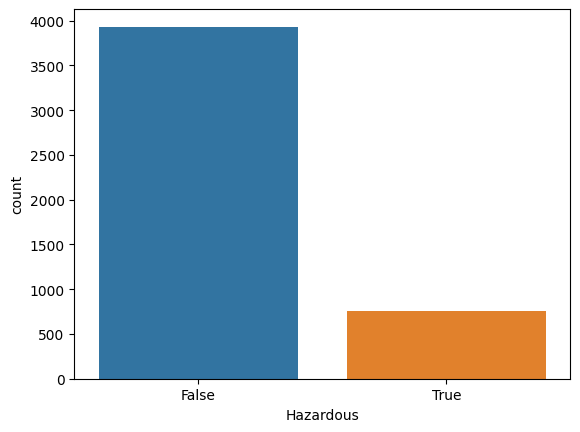

In [6]:
print( df_nasa.Hazardous.value_counts() )
sns.countplot(x='Hazardous', data=df_nasa, hue='Hazardous', legend=False)

# Correlación de Variables

<Axes: >

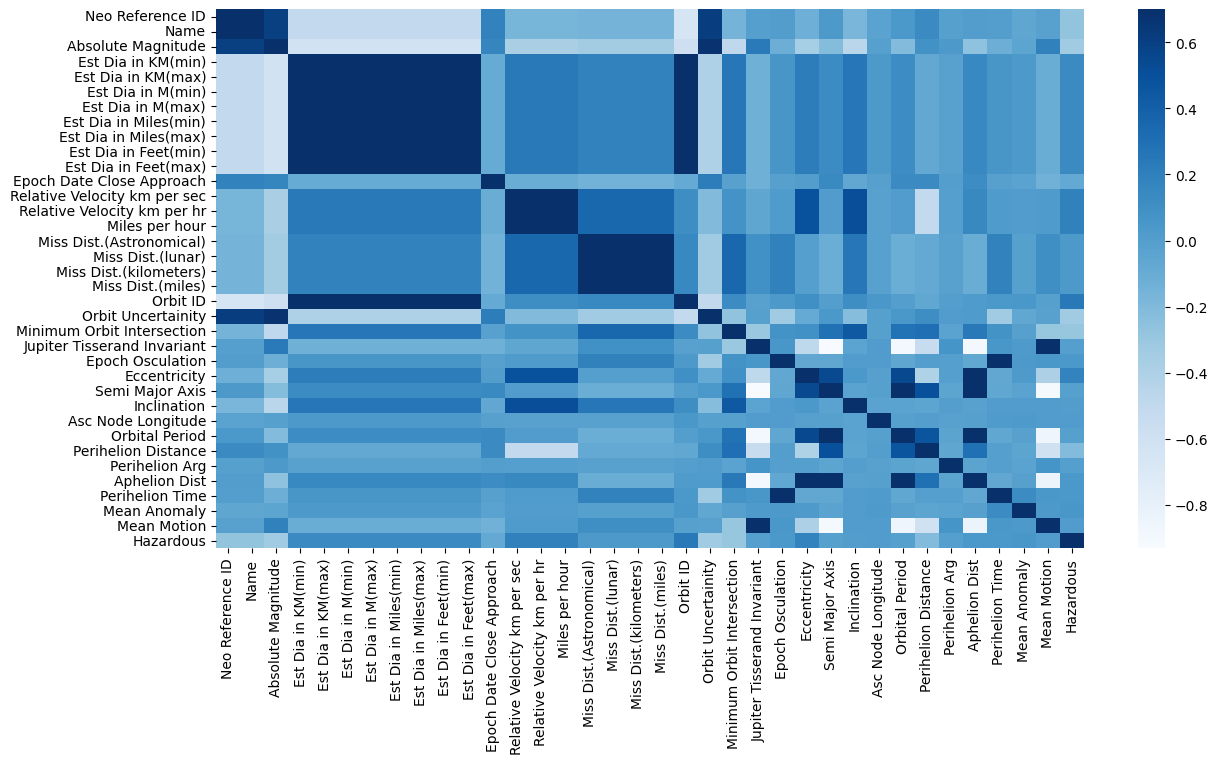

In [7]:
plt.figure(figsize=(14,7))
sns.heatmap(df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr(), vmax=.7, cmap ='Blues', fmt=".2f")

In [8]:
df_nasa_corr = df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr()[["Hazardous"]]*100 # Lo pasamos a porcentajes
df_nasa_corr = df_nasa_corr.drop("Hazardous", axis=0) # Eliminamos la variable target
df_nasa_corr = abs(df_nasa_corr) # Nos interesa el valor absoluto
df_nasa_corr = df_nasa_corr.sort_values(["Hazardous"], ascending=False) # Ordenamos en forma descendente
df_nasa_corr

,Hazardous
Orbit Uncertainity,32.872134
Absolute Magnitude,32.552193
Minimum Orbit Intersection,28.894902
Name,26.902814
Neo Reference ID,26.902814
Orbit ID,24.736904
Perihelion Distance,20.702693
Relative Velocity km per sec,19.197018
Miles per hour,19.197018
Relative Velocity km per hr,19.197018


# Seleccionamos las variables que vamos a utilizar y hacemos el Split

Dropeo ['Orbiting Body','Equinox'] porque en todos los casos es earth y J2000

In [9]:
df_nasa.drop(['Orbiting Body','Equinox'],axis=1, inplace=True)

In [10]:
df_nasa.columns

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit ID',
       'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Hazardous'],
      dtype='object')

In [11]:
df = df_nasa.drop(['Close Approach Date','Orbit Determination Date'],axis=1)
X_nasa = df.drop("Hazardous",axis=1)
y_nasa = df["Hazardous"]
X_nasa.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


Hacemos el Split 70-30 para train-test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_nasa, y_nasa, test_size=0.3, stratify = y_nasa, random_state=0)

Creamos y entrenamos el clasificador bayesiano

In [13]:
bayes_multi = MultinomialNB()
bayes_multi.fit(X_train, y_train) # Entrenamos el clasificador

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [14]:
y_pred_nb = bayes_multi.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_nb)*100))
print("-"*100)

# Reporte del clasificador
print(classification_report(y_test,y_pred_nb))

Exactitud (accuracy) del modelo: 49.96 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.85      0.49      0.62      1180
        True       0.17      0.55      0.26       227

    accuracy                           0.50      1407
   macro avg       0.51      0.52      0.44      1407
weighted avg       0.74      0.50      0.56      1407



In [15]:
# Importamos otra librería para modelos naive bayes gausianos
from sklearn.naive_bayes import GaussianNB # naive bayes multinomial para clasificación

bayes_gauss = GaussianNB()
bayes_gauss.fit(X_train, y_train) # entrenamos el clasificador

,priors,None
,var_smoothing,1e-09


In [16]:
# Calculamos y mostramos la matriz de confusión del modelo
y_pred_gauss = bayes_gauss.predict(X_test)
#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_gauss)*100))
print("-"*100)

print(classification_report(y_test,y_pred_gauss))

Exactitud (accuracy) del modelo: 83.87 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.84      1.00      0.91      1180
        True       0.00      0.00      0.00       227

    accuracy                           0.84      1407
   macro avg       0.42      0.50      0.46      1407
weighted avg       0.70      0.84      0.77      1407



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

---
# Ejercicios

---
## Ejercicio 1

Identificar el parametro que estratifica el split del experimento

El parámetro que estratifica el split es: 'stratify = y_nasa'

¿Qué significa esto? Estratificar significa mantener la misma proporción de clases entre el conjunto de entrenamiento y el conjunto de prueba.

Verificar las proporciones

In [17]:
print("Proporciones en el dataset completo:")
print(y_nasa.value_counts(normalize=True))

Proporciones en el dataset completo:
Hazardous
False    0.838916
True     0.161084
Name: proportion, dtype: float64


In [18]:
print("Proporciones en conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

Proporciones en conjunto de entrenamiento:
Hazardous
False    0.839024
True     0.160976
Name: proportion, dtype: float64


In [19]:
print("Proporciones en conjunto de prueba:")
print(y_test.value_counts(normalize=True))

Proporciones en conjunto de prueba:
Hazardous
False    0.838664
True     0.161336
Name: proportion, dtype: float64


---
## Ejercicio 2

¿Cómo se compara el performance del modelo de bayes multinomial con el de bayes gaussiano? Basado en las métricas, ¿Cúal de los modelos es más útil?

### 2.1 - Calculamos métricas para ambos modelos

In [20]:
accuracy_multinomial = accuracy_score(y_test, y_pred_nb)
accuracy_gaussiano = accuracy_score(y_test, y_pred_gauss)

### 2.2 - Comparación de Performance

In [21]:
print(f"Naive Bayes Multinomial: {accuracy_multinomial:.4f} ({accuracy_multinomial*100:.2f}%)")
print(f"Naive Bayes Gaussiano:   {accuracy_gaussiano:.4f} ({accuracy_gaussiano*100:.2f}%)")

Naive Bayes Multinomial: 0.4996 (49.96%)
Naive Bayes Gaussiano:   0.8387 (83.87%)


### 2.3 - Análisis detallado

In [22]:
diferencia = accuracy_gaussiano - accuracy_multinomial
print(f"Diferencia: {diferencia:.4f} ({diferencia*100:.2f} puntos porcentuales)")

if accuracy_gaussiano > accuracy_multinomial:
    mejor_modelo = "Gaussiano"
    print(f"El modelo {mejor_modelo} es superior")
else:
    mejor_modelo = "Multinomial"
    print(f"El modelo {mejor_modelo} es superior")

Diferencia: 0.3390 (33.90 puntos porcentuales)
El modelo Gaussiano es superior


Explicación
- Naive Bayes Multinomial: Asume distribución multinomial de las features.
- Naive Bayes Gaussiano: Asume distribución normal de las features.
- Para datos continuos como los de NASA, Gaussiano suele ser más apropiado.

Conclusión

In [23]:
print(f"El modelo {mejor_modelo} es más útil para este dataset")

El modelo Gaussiano es más útil para este dataset


---
## Ejercicio 3

Remover las variables redundantes/altamente codependientes como 'Est Dia in M(min)' y 'Est Dia in Miles(min)'

### 3.1 - Encontrar pares con alta correlación

In [24]:
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val > 0.8:  # Umbral de alta correlación
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            high_corr_pairs.append((var1, var2, corr_val))

Pares de variables con correlación > 0.8

In [25]:
for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f"{var1:<25} - {var2:<25}: {corr:.3f}")

Est Dia in KM(min)        - Est Dia in Feet(min)     : 1.000
Est Dia in M(min)         - Est Dia in M(max)        : 1.000
Est Dia in Miles(min)     - Est Dia in Feet(min)     : 1.000
Est Dia in KM(min)        - Est Dia in Feet(max)     : 1.000
Est Dia in KM(min)        - Est Dia in KM(max)       : 1.000
Est Dia in Feet(min)      - Est Dia in Feet(max)     : 1.000
Est Dia in KM(max)        - Est Dia in Feet(min)     : 1.000
Est Dia in M(max)         - Est Dia in Miles(min)    : 1.000
Est Dia in KM(max)        - Est Dia in M(max)        : 1.000
Est Dia in KM(min)        - Est Dia in Miles(max)    : 1.000
Est Dia in KM(min)        - Est Dia in M(min)        : 1.000
Est Dia in M(min)         - Est Dia in Feet(min)     : 1.000
Est Dia in M(max)         - Est Dia in Feet(min)     : 1.000
Relative Velocity km per sec - Miles per hour           : 1.000
Est Dia in KM(min)        - Est Dia in Miles(min)    : 1.000
Est Dia in Miles(max)     - Est Dia in Feet(min)     : 1.000
Est Dia in KM(max)   

In [26]:
print(f"\nTotal de pares con alta correlación: {len(high_corr_pairs)}")


Total de pares con alta correlación: 49


### 3.2 - Función para eliminar multicolinealidad: Elimina variables con alta correlación, conservando la más correlacionada con el target

In [27]:
def eliminar_multicolinealidad(df, target_col, umbral_corr=0.8):
    # Incluir el target en el DataFrame completo para calcular correlaciones
    correlation_matrix_completa = df.corr()
    
    # Obtener solo las features (sin el target)
    features = [col for col in df.columns if col != target_col and df[col].dtype in ['int64', 'float64']]
    
    # Matriz de correlación entre features
    correlation_matrix_features = df[features].corr()
    
    # Correlación de cada feature con el target
    target_corr = correlation_matrix_completa[target_col].abs()
    
    variables_eliminadas = set()
    
    print("Analizando pares de variables con alta correlación...")
    print("-" * 70)
    
    for i, var1 in enumerate(features):
        if var1 in variables_eliminadas:
            continue
            
        for j in range(i+1, len(features)):
            var2 = features[j]
            if var2 in variables_eliminadas:
                continue
                
            corr_between_vars = abs(correlation_matrix_features.loc[var1, var2])
            
            if corr_between_vars > umbral_corr:
                # Conservar la variable más correlacionada con el target
                corr_var1_target = target_corr[var1] if var1 in target_corr.index else 0
                corr_var2_target = target_corr[var2] if var2 in target_corr.index else 0
                
                if corr_var1_target >= corr_var2_target:
                    variables_eliminadas.add(var2)
                    print(f"Eliminando: {var2}")
                    print(f"  Correlación con target: {corr_var2_target:.3f}")
                    print(f"Conservando: {var1}")
                    print(f"  Correlación con target: {corr_var1_target:.3f}")
                else:
                    variables_eliminadas.add(var1)
                    print(f"Eliminando: {var1}")
                    print(f"  Correlación con target: {corr_var1_target:.3f}")
                    print(f"Conservando: {var2}")
                    print(f"  Correlación con target: {corr_var2_target:.3f}")
                
                print(f"  Correlación entre variables: {corr_between_vars:.3f}")
                print("-" * 50)
    
    variables_finales = [var for var in features if var not in variables_eliminadas]
    return variables_finales, list(variables_eliminadas)

### 3.3 - Aplicamos la función

In [28]:
variables_finales, variables_eliminadas = eliminar_multicolinealidad(df, 'Hazardous', umbral_corr=0.8)

Analizando pares de variables con alta correlación...
----------------------------------------------------------------------
Eliminando: Name
  Correlación con target: 0.269
Conservando: Neo Reference ID
  Correlación con target: 0.269
  Correlación entre variables: 1.000
--------------------------------------------------
Eliminando: Est Dia in KM(min)
  Correlación con target: 0.132
Conservando: Est Dia in KM(max)
  Correlación con target: 0.132
  Correlación entre variables: 1.000
--------------------------------------------------
Eliminando: Est Dia in KM(min)
  Correlación con target: 0.132
Conservando: Est Dia in M(min)
  Correlación con target: 0.132
  Correlación entre variables: 1.000
--------------------------------------------------
Eliminando: Est Dia in KM(min)
  Correlación con target: 0.132
Conservando: Est Dia in M(max)
  Correlación con target: 0.132
  Correlación entre variables: 1.000
--------------------------------------------------
Eliminando: Est Dia in Miles(min)

### 3.4 - Resumen

In [29]:
print(f"Variables numéricas originales: {len([col for col in df.columns if col != 'Hazardous' and df[col].dtype in ['int64', 'float64']])}")
print(f"Variables eliminadas: {len(variables_eliminadas)}")
print(f"Variables conservadas: {len(variables_finales)}")

Variables numéricas originales: 35
Variables eliminadas: 18
Variables conservadas: 17


In [30]:
if variables_eliminadas:
    print(f"Variables eliminadas: {variables_eliminadas}")
else:
    print(f"No se encontraron variables con correlación > {0.8}")

Variables eliminadas: ['Miles per hour', 'Jupiter Tisserand Invariant', 'Est Dia in Miles(min)', 'Relative Velocity km per hr', 'Est Dia in KM(min)', 'Est Dia in Feet(min)', 'Name', 'Semi Major Axis', 'Miss Dist.(Astronomical)', 'Est Dia in KM(max)', 'Mean Motion', 'Orbital Period', 'Est Dia in Feet(max)', 'Est Dia in M(max)', 'Perihelion Time', 'Miss Dist.(miles)', 'Miss Dist.(kilometers)', 'Est Dia in M(min)']


### 3.5 - Crear dataset filtrado y entrenar modelo

#### 3.5.1 - Obtener accuracy original para comparación

In [31]:
accuracy_gauss_original = accuracy_score(y_test, y_pred_gauss)

#### 3.5.2 - Verificar que existen variables para trabajar

In [32]:
if len(variables_finales) > 0:
    df_filtrado = df[variables_finales + ['Hazardous']]
    X_filtrado = df_filtrado.drop('Hazardous', axis=1)
    y_filtrado = df_filtrado['Hazardous']

    print(f"Variables utilizadas: {variables_finales}")
    print(f"Forma del dataset filtrado: {df_filtrado.shape}")

    # Split
    X_train_filt, X_test_filt, y_train_filt, y_test_filt = train_test_split(X_filtrado, y_filtrado, test_size=0.3, stratify=y_filtrado, random_state=0)

    # Entrenar modelo Gaussiano filtrado
    print("\nEntrenando Naive Bayes Gaussiano con variables filtradas...")
    nb_gauss_filt = GaussianNB()
    nb_gauss_filt.fit(X_train_filt, y_train_filt)
    y_pred_gauss_filt = nb_gauss_filt.predict(X_test_filt)
    accuracy_gauss_filtrado = accuracy_score(y_test_filt, y_pred_gauss_filt)

    # Entrenar modelo Multinomial filtrado
    print("Entrenando Naive Bayes Multinomial con variables filtradas...")
    nb_multi_filt = MultinomialNB()
    nb_multi_filt.fit(X_train_filt, y_train_filt)
    y_pred_multi_filt = nb_multi_filt.predict(X_test_filt)
    accuracy_multi_filtrado = accuracy_score(y_test_filt, y_pred_multi_filt)

    # Comparar resultados
    print("\nCOMPARACIÓN DE RESULTADOS:")
    print("-" * 50)
    print(f"Gaussiano (original):   {accuracy_gauss_original:.4f} ({accuracy_gauss_original*100:.2f}%)")
    print(f"Gaussiano (filtrado):   {accuracy_gauss_filtrado:.4f} ({accuracy_gauss_filtrado*100:.2f}%)")
    print(f"Multinomial (filtrado): {accuracy_multi_filtrado:.4f} ({accuracy_multi_filtrado*100:.2f}%)")

    mejora_gauss = accuracy_gauss_filtrado - accuracy_gauss_original
    print(f"\nCambio con filtrado Gaussiano: {mejora_gauss:+.4f} ({mejora_gauss*100:+.2f} pp)")
    
    if mejora_gauss > 0:
        print("La eliminación de multicolinealidad MEJORÓ el modelo Gaussiano")
    elif mejora_gauss < -0.01:
        print("La eliminación de multicolinealidad empeoró el modelo Gaussiano")
    else:
        print("La eliminación de multicolinealidad no tuvo impacto significativo")
else:
    print("No hay variables disponibles después del filtrado")
    print("Usando dataset original...")
    
    # Usar dataset original
    accuracy_gauss_filtrado = accuracy_gauss_original
    accuracy_multi_filtrado = accuracy_score(y_test, y_pred_nb)  # Usar modelo multinomial original
    y_pred_gauss_filt = y_pred_gauss
    y_pred_multi_filt = y_pred_nb
    y_test_filt = y_test
    mejora_gauss = 0

Variables utilizadas: ['Neo Reference ID', 'Absolute Magnitude', 'Est Dia in Miles(max)', 'Epoch Date Close Approach', 'Relative Velocity km per sec', 'Miss Dist.(lunar)', 'Orbit ID', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Epoch Osculation', 'Eccentricity', 'Inclination', 'Asc Node Longitude', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly']
Forma del dataset filtrado: (4687, 18)

Entrenando Naive Bayes Gaussiano con variables filtradas...
Entrenando Naive Bayes Multinomial con variables filtradas...

COMPARACIÓN DE RESULTADOS:
--------------------------------------------------
Gaussiano (original):   0.8387 (83.87%)
Gaussiano (filtrado):   0.8387 (83.87%)
Multinomial (filtrado): 0.7392 (73.92%)

Cambio con filtrado Gaussiano: +0.0000 (+0.00 pp)
La eliminación de multicolinealidad no tuvo impacto significativo


#### 3.5.3 - Determinar mejor modelo

In [33]:
if accuracy_gauss_filtrado >= accuracy_multi_filtrado:
    mejor_modelo_filt = "Gaussiano"
    mejor_pred = y_pred_gauss_filt
    mejor_accuracy = accuracy_gauss_filtrado
else:
    mejor_modelo_filt = "Multinomial"
    mejor_pred = y_pred_multi_filt
    mejor_accuracy = accuracy_multi_filtrado

print(f"Mejor modelo con variables filtradas: {mejor_modelo_filt}")
print(f"Exactitud: {mejor_accuracy:.4f} ({mejor_accuracy*100:.2f}%)")

Mejor modelo con variables filtradas: Gaussiano
Exactitud: 0.8387 (83.87%)


#### 3.5.4 - Reporte de Clasificación

In [34]:
print(classification_report(y_test_filt, mejor_pred))

              precision    recall  f1-score   support

       False       0.84      1.00      0.91      1180
        True       0.00      0.00      0.00       227

    accuracy                           0.84      1407
   macro avg       0.42      0.50      0.46      1407
weighted avg       0.70      0.84      0.77      1407



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

---
## Ejercicio 4

¿Que pasa con el accuracy en este ejercicio? ¿es el mejor indicador posible?

### 4.1 - Analizar el Balance de Clases

In [35]:
clase_counts = y_nasa.value_counts()
clase_props = y_nasa.value_counts(normalize=True)

### 4.2 - Distribución de Clases

In [36]:
for clase in clase_counts.index:
    count = clase_counts[clase]
    prop = clase_props[clase]
    print(f"  {clase}: {count} ({prop:.1%})")

  False: 3932 (83.9%)
  True: 755 (16.1%)


### 4.3 - Calcular Métricas Adicionales

Métricas detallas: Modelo Gaussiano filtrado

In [37]:
precision = precision_score(y_test_filt, y_pred_gauss_filt, pos_label=True)
recall = recall_score(y_test_filt, y_pred_gauss_filt, pos_label=True)
f1 = f1_score(y_test_filt, y_pred_gauss_filt, pos_label=True)

print(f"Accuracy:  {accuracy_gauss_filtrado:.4f}")
print(f"Precision: {precision:.4f} (De los asteroides predichos como peligrosos, qué % realmente lo son)")
print(f"Recall:    {recall:.4f} (De los asteroides realmente peligrosos, qué % detectamos)")
print(f"F1-Score:  {f1:.4f} (Media armónica de precision y recall)")

Accuracy:  0.8387
Precision: 0.0000 (De los asteroides predichos como peligrosos, qué % realmente lo son)
Recall:    0.0000 (De los asteroides realmente peligrosos, qué % detectamos)
F1-Score:  0.0000 (Media armónica de precision y recall)


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 4.4 - Matriz de Confusión

In [38]:
cm = confusion_matrix(y_test_filt, y_pred_gauss_filt)
print(f"\nMATRIZ DE CONFUSIÓN:")
print("                 Predicho")
print("                No  Sí")
print(f"Real    No    {cm[0,0]:4} {cm[0,1]:3}")
print(f"        Sí    {cm[1,0]:4} {cm[1,1]:3}")


MATRIZ DE CONFUSIÓN:
                 Predicho
                No  Sí
Real    No    1180   0
        Sí     227   0


Análisis del problema específico

Para asteroides peligrosos
- FALSOS NEGATIVOS son MUY COSTOSOS (no detectar un asteroide peligroso)
- FALSOS POSITIVOS son menos costosos (falsa alarma)

Por tanto
- RECALL es más importante que Precision
- Accuracy puede ser engañoso si las clases están desbalanceadas

Recomendación

In [39]:
balance_threshold = 0.7
es_desbalanceado = clase_props[False] > balance_threshold

if es_desbalanceado:
    print("Dataset Desbalanceado: El accuracy puede ser engañoso. Un modelo que siempre prediga 'No peligroso' tendría alta accuracy, pero sería inútil para detectar asteroides realmente peligrosos.")
    print("Métricas Recomendadas:")
    print("• Recall (Para no perder asteroides peligrosos)")
    print("• F1-Score (Balance entre precision y recall)")
    print("• AUC-ROC (Área bajo la curva ROC)")
else:
    print("Dataset relativamente balanceado, accuracy es una métrica aceptable. Sin embargo, para detección de asteroides peligrosos, sigue siendo recomendable enfocarse en Recall.")

Dataset Desbalanceado: El accuracy puede ser engañoso. Un modelo que siempre prediga 'No peligroso' tendría alta accuracy, pero sería inútil para detectar asteroides realmente peligrosos.
Métricas Recomendadas:
• Recall (Para no perder asteroides peligrosos)
• F1-Score (Balance entre precision y recall)
• AUC-ROC (Área bajo la curva ROC)


### 4.5 - Visualización Comparativa Completa

Asegurar que tenemos todas las variables necesarias

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


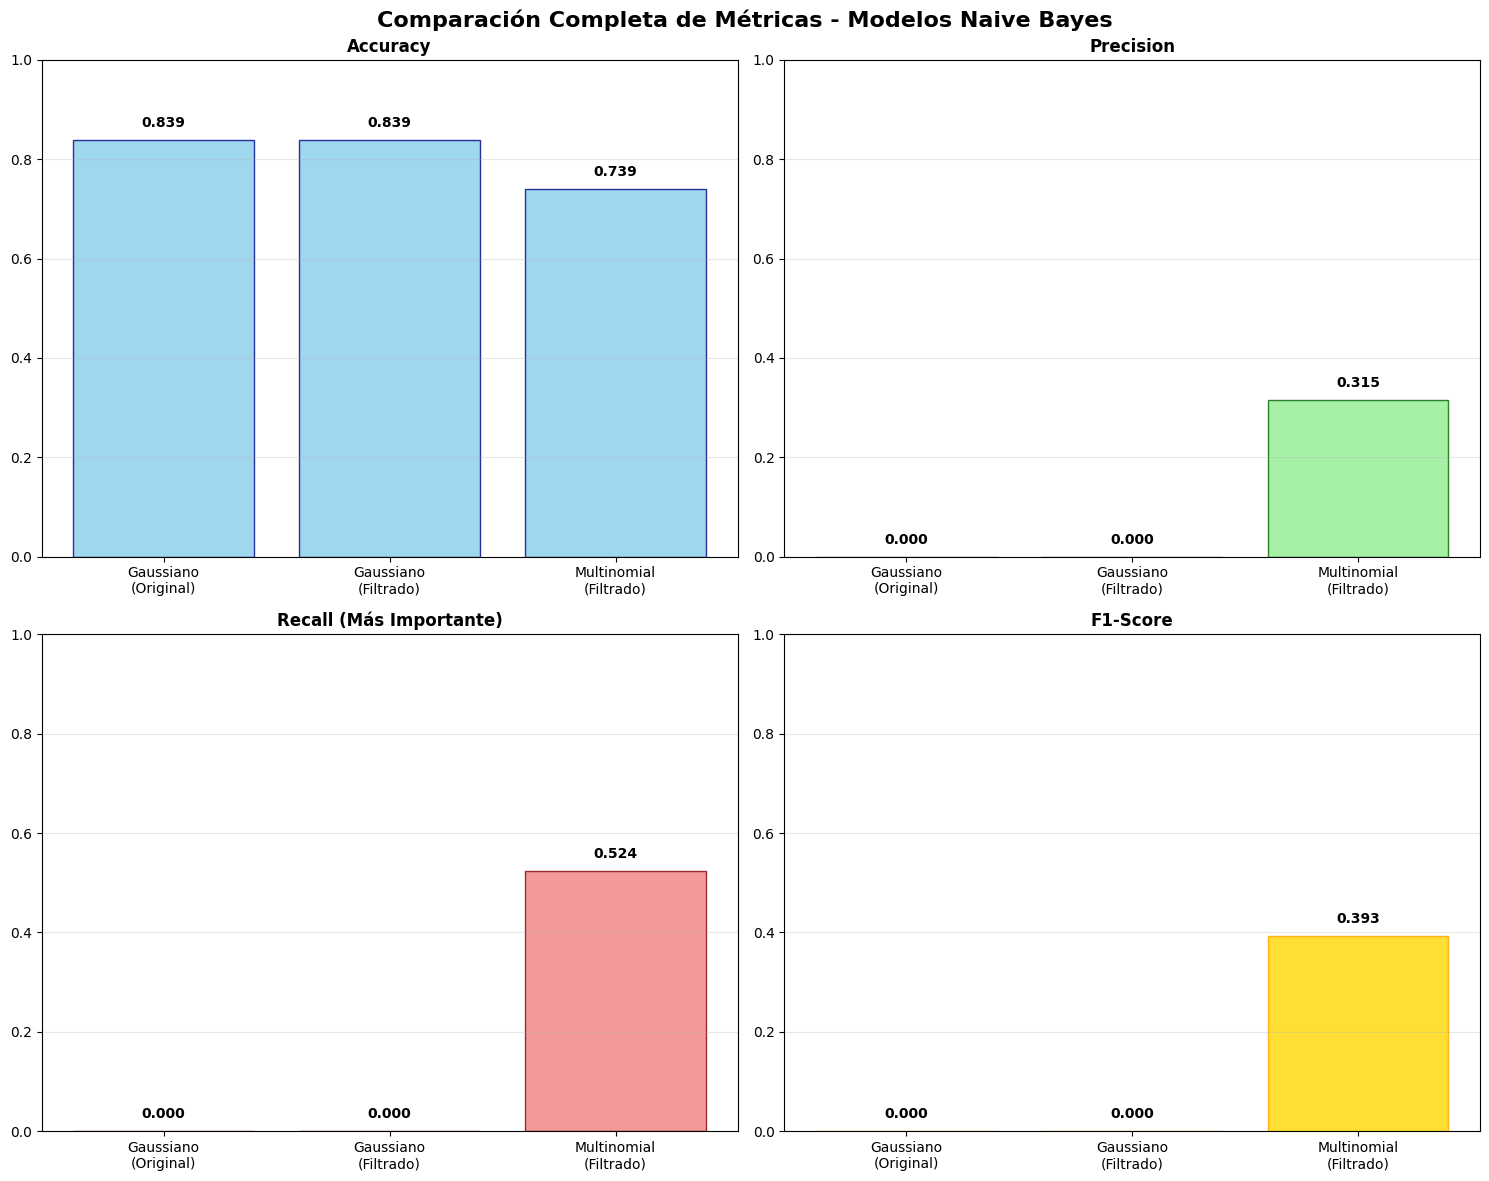

TABLA COMPARATIVA DETALLADA
Modelo                    Accuracy   Precision    Recall     F1-Score  
--------------------------------------------------------------------------------
Gaussiano (Original)      0.8387     0.0000       0.0000     0.0000    
Gaussiano (Filtrado)      0.8387     0.0000       0.0000     0.0000    
Multinomial (Filtrado)    0.7392     0.3148       0.5242     0.3934    


In [40]:
if 'y_pred_gauss_filt' in locals() and 'y_test_filt' in locals():
    # Datos para el gráfico
    if len(variables_finales) > 0:
        modelos = ['Gaussiano\n(Original)', 'Gaussiano\n(Filtrado)', 'Multinomial\n(Filtrado)']
        accuracies = [accuracy_gauss_original, accuracy_gauss_filtrado, accuracy_multi_filtrado]
        
        # Calcular precision, recall y f1 para todos los modelos
        precisions = [
            precision_score(y_test, y_pred_gauss, pos_label=True),
            precision_score(y_test_filt, y_pred_gauss_filt, pos_label=True),
            precision_score(y_test_filt, y_pred_multi_filt, pos_label=True)
        ]
        
        recalls = [
            recall_score(y_test, y_pred_gauss, pos_label=True),
            recall_score(y_test_filt, y_pred_gauss_filt, pos_label=True),
            recall_score(y_test_filt, y_pred_multi_filt, pos_label=True)
        ]
        
        f1_scores = [
            f1_score(y_test, y_pred_gauss, pos_label=True),
            f1_score(y_test_filt, y_pred_gauss_filt, pos_label=True),
            f1_score(y_test_filt, y_pred_multi_filt, pos_label=True)
        ]
    else:
        # Si no hay variables filtradas, comparar solo los originales
        modelos = ['Gaussiano\n(Original)', 'Multinomial\n(Original)']
        accuracies = [accuracy_gauss_original, accuracy_score(y_test, y_pred_nb)]
        
        precisions = [
            precision_score(y_test, y_pred_gauss, pos_label=True),
            precision_score(y_test, y_pred_nb, pos_label=True)
        ]
        
        recalls = [
            recall_score(y_test, y_pred_gauss, pos_label=True),
            recall_score(y_test, y_pred_nb, pos_label=True)
        ]
        
        f1_scores = [
            f1_score(y_test, y_pred_gauss, pos_label=True),
            f1_score(y_test, y_pred_nb, pos_label=True)
        ]

    # Crear gráfico comparativo
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Comparación Completa de Métricas - Modelos Naive Bayes', fontsize=16, fontweight='bold')

    # Accuracy
    bars1 = axes[0,0].bar(modelos, accuracies, color='skyblue', alpha=0.8, edgecolor='navy')
    axes[0,0].set_title('Accuracy', fontweight='bold')
    axes[0,0].set_ylim(0, 1)
    axes[0,0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(accuracies):
        axes[0,0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    # Precision
    bars2 = axes[0,1].bar(modelos, precisions, color='lightgreen', alpha=0.8, edgecolor='darkgreen')
    axes[0,1].set_title('Precision', fontweight='bold')
    axes[0,1].set_ylim(0, 1)
    axes[0,1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(precisions):
        axes[0,1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    # Recall
    bars3 = axes[1,0].bar(modelos, recalls, color='lightcoral', alpha=0.8, edgecolor='darkred')
    axes[1,0].set_title('Recall (Más Importante)', fontweight='bold')
    axes[1,0].set_ylim(0, 1)
    axes[1,0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(recalls):
        axes[1,0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    # F1-Score
    bars4 = axes[1,1].bar(modelos, f1_scores, color='gold', alpha=0.8, edgecolor='orange')
    axes[1,1].set_title('F1-Score', fontweight='bold')
    axes[1,1].set_ylim(0, 1)
    axes[1,1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(f1_scores):
        axes[1,1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    # Ajustar layout
    plt.tight_layout()
    plt.show()

    # Tabla comparativa detallada
    print("="*80)
    print("TABLA COMPARATIVA DETALLADA")
    print("="*80)
    print(f"{'Modelo':<25} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 80)
    
    for i, modelo in enumerate(modelos):
        modelo_clean = modelo.replace('\n', ' ')
        print(f"{modelo_clean:<25} {accuracies[i]:<10.4f} {precisions[i]:<12.4f} {recalls[i]:<10.4f} {f1_scores[i]:<10.4f}")

else:
    print("No se pudieron calcular todas las métricas necesarias para la visualización completa")

### 4.6 - Conclusiones Finales Completas

Determinar el mejor modelo basado en múltiples métricas

In [41]:
if 'accuracies' in locals() and len(accuracies) > 0:
    # Índice del mejor modelo por cada métrica
    best_accuracy_idx = accuracies.index(max(accuracies))
    best_recall_idx = recalls.index(max(recalls))
    best_f1_idx = f1_scores.index(max(f1_scores))
    
    print("🏆 MEJORES MODELOS POR MÉTRICA:")
    print(f"   • Mejor Accuracy: {modelos[best_accuracy_idx].replace(chr(10), ' ')} ({accuracies[best_accuracy_idx]:.4f})")
    print(f"   • Mejor Recall: {modelos[best_recall_idx].replace(chr(10), ' ')} ({recalls[best_recall_idx]:.4f})")
    print(f"   • Mejor F1-Score: {modelos[best_f1_idx].replace(chr(10), ' ')} ({f1_scores[best_f1_idx]:.4f})")
    
    # Modelo recomendado (priorizando recall para asteroides peligrosos)
    modelo_recomendado = modelos[best_recall_idx].replace('\n', ' ')
    print(f"\n🎯 MODELO RECOMENDADO: {modelo_recomendado}")
    print(f"   Razón: Mayor Recall ({recalls[best_recall_idx]:.4f}) - Crítico para detectar asteroides peligrosos")
    
    print(f"\n📊 RESPUESTA AL EJERCICIO 4:")
    print(f"   ¿Es accuracy el mejor indicador?")
    if es_desbalanceado:
        print(f"   ❌ NO - El dataset está desbalanceado ({clase_props[False]*100:.1f}% no peligrosos)")
        print(f"   ✅ MEJOR: Recall y F1-Score son más informativos")
        print(f"   📈 Recall es CRÍTICO: evitar falsos negativos en asteroides peligrosos")
    else:
        print(f"   ⚠️  PARCIALMENTE - Aunque el dataset está balanceado,")
        print(f"   ✅ MEJOR: Recall sigue siendo más importante por el contexto del problema")
    
    # Evaluación de la eliminación de multicolinealidad
    if len(variables_finales) > 0 and 'mejora_gauss' in locals():
        print(f"\n🔧 ELIMINACIÓN DE MULTICOLINEALIDAD:")
        if mejora_gauss > 0.01:
            print(f"   ✅ EFECTIVA: Mejoró el modelo en {mejora_gauss:.4f} puntos")
        elif mejora_gauss < -0.01:
            print(f"   ❌ CONTRAPRODUCENTE: Empeoró el modelo en {abs(mejora_gauss):.4f} puntos")
        else:
            print(f"   ➡️  NEUTRAL: Sin impacto significativo ({mejora_gauss:+.4f} puntos)")
        
        if variables_eliminadas:
            print(f"   📋 Variables eliminadas: {len(variables_eliminadas)}")
            # Verificar si se eliminaron variables del enunciado
            vars_enunciado = [var for var in variables_eliminadas if any(word in var.lower() for word in ['dia', 'mile'])]
            if vars_enunciado:
                print(f"   ✅ Incluyó variables relacionadas con el enunciado: {vars_enunciado}")
    
    print(f"\n💡 RECOMENDACIONES PRÁCTICAS:")
    print(f"   1. Usar {modelo_recomendado} para producción")
    print(f"   2. Monitorear principalmente Recall y F1-Score")
    print(f"   3. Establecer umbral de decisión conservador (priorizar detección)")
    print(f"   4. Validar regularmente con nuevos datos de asteroides")
    
else:
    print("No se pudieron generar conclusiones completas debido a datos faltantes")

🏆 MEJORES MODELOS POR MÉTRICA:
   • Mejor Accuracy: Gaussiano (Original) (0.8387)
   • Mejor Recall: Multinomial (Filtrado) (0.5242)
   • Mejor F1-Score: Multinomial (Filtrado) (0.3934)

🎯 MODELO RECOMENDADO: Multinomial (Filtrado)
   Razón: Mayor Recall (0.5242) - Crítico para detectar asteroides peligrosos

📊 RESPUESTA AL EJERCICIO 4:
   ¿Es accuracy el mejor indicador?
   ❌ NO - El dataset está desbalanceado (83.9% no peligrosos)
   ✅ MEJOR: Recall y F1-Score son más informativos
   📈 Recall es CRÍTICO: evitar falsos negativos en asteroides peligrosos

🔧 ELIMINACIÓN DE MULTICOLINEALIDAD:
   ➡️  NEUTRAL: Sin impacto significativo (+0.0000 puntos)
   📋 Variables eliminadas: 18
   ✅ Incluyó variables relacionadas con el enunciado: ['Miles per hour', 'Est Dia in Miles(min)', 'Est Dia in KM(min)', 'Est Dia in Feet(min)', 'Est Dia in KM(max)', 'Est Dia in Feet(max)', 'Est Dia in M(max)', 'Miss Dist.(miles)', 'Est Dia in M(min)']

💡 RECOMENDACIONES PRÁCTICAS:
   1. Usar Multinomial (Filtra